<a href="https://colab.research.google.com/github/nirmalmndl2007-pixel/CODSOFT_TASKS/blob/main/Task1_Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# CODSOFT DATA SCIENCE INTERNSHIP
# TASK 1: TITANIC SURVIVAL PREDICTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Check dataset information
print("Dataset Information:")
print("--------------------")

df.info()

Dataset Information:
--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Statistical summary of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


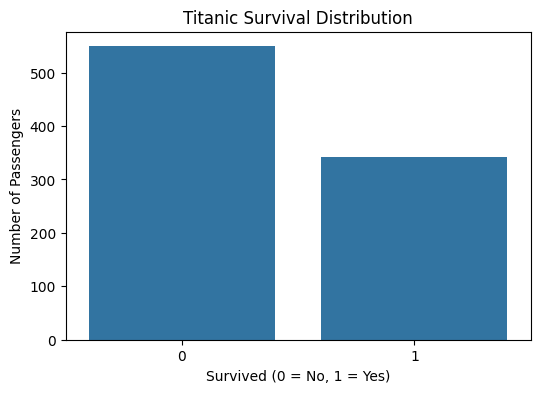

In [ ]:
# Survival distribution

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Survived")

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

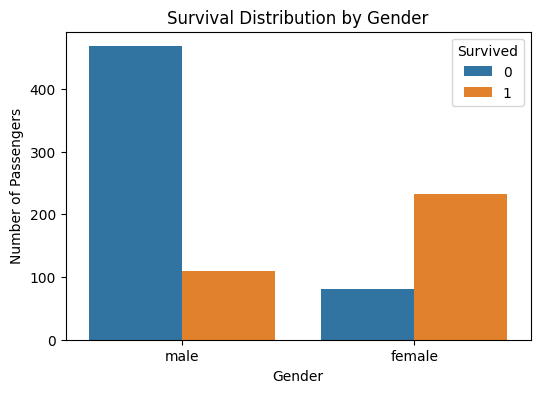

In [ ]:
# Survival distribution by gender

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

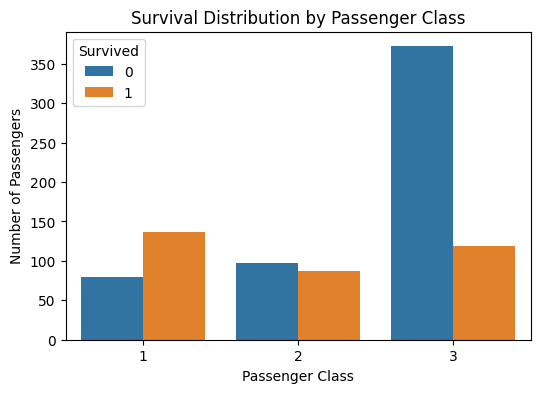

In [ ]:
# Survival distribution by passenger class

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

In [ ]:
# Select features for the machine learning model

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

print("Features selected:")
print(features)

print("\nTarget variable:")
print("Survived")

Features selected:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Target variable:
Survived


In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


In [ ]:
# Define numerical and categorical features

numeric_features = [
    "Age",
    "Fare",
    "Pclass",
    "SibSp",
    "Parch"
]

categorical_features = [
    "Sex",
    "Embarked"
]

# Preprocessing for numerical features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Preprocessing for categorical features
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
# Create machine learning pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Make predictions on the test dataset

y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!

First 20 predictions:
[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [ ]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 80.45 %


In [ ]:
# Detailed model evaluation

print("Classification Report")
print("=====================")

print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



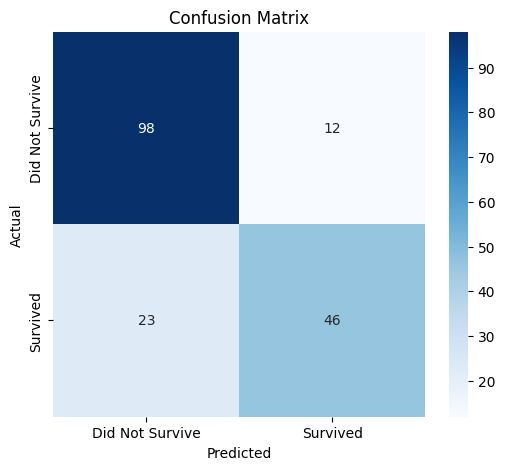

In [ ]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Create a hypothetical passenger

new_passenger = pd.DataFrame({
    "Pclass": [1],
    "Sex": ["female"],
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [80],
    "Embarked": ["S"]
})

# Make prediction
prediction = model.predict(new_passenger)[0]

# Get probability
probability = model.predict_proba(new_passenger)[0]

if prediction == 1:
    result = "Survived"
else:
    result = "Did Not Survive"

print("Predicted outcome:", result)

print("\nPrediction probabilities:")
print("Did not survive:", round(probability[0] * 100, 2), "%")
print("Survived:", round(probability[1] * 100, 2), "%")

Predicted outcome: Survived

Prediction probabilities:
Did not survive: 5.81 %
Survived: 94.19 %


In [ ]:
# Save the trained model

import joblib

joblib.dump(model, "titanic_survival_model.pkl")

print("Model saved successfully!")
print("File: titanic_survival_model.pkl")

Model saved successfully!
File: titanic_survival_model.pkl


In [ ]:
# Final project summary

print("=" * 55)
print("CODSOFT - TASK 1")
print("TITANIC SURVIVAL PREDICTION")
print("=" * 55)

print(f"Dataset size: {df.shape[0]} passengers")
print(f"Number of features used: {len(features)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("Algorithm: Logistic Regression")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("=" * 55)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 55)

CODSOFT - TASK 1
TITANIC SURVIVAL PREDICTION
Dataset size: 891 passengers
Number of features used: 7
Training samples: 712
Testing samples: 179
Algorithm: Logistic Regression
Accuracy: 80.45%
PROJECT COMPLETED SUCCESSFULLY!
